In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt

with open('../datasets/mod_05_topic_10_various_data.pkl', 'rb') as fl:
    datasets = pickle.load(fl)

In [2]:
datasets.keys()

dict_keys(['autos', 'concrete', 'customer', 'accidents'])

In [3]:
df = datasets['autos']
df

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,13495
1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9,111,5000,21,27,16500
2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
3,audi,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10,102,5500,24,30,13950
4,audi,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,141,mpfi,3.78,3.15,9,114,5400,23,28,16845
189,volvo,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,...,141,mpfi,3.78,3.15,8,160,5300,19,25,19045
190,volvo,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,...,173,mpfi,3.58,2.87,8,134,5500,18,23,21485
191,volvo,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,...,145,idi,3.01,3.40,23,106,4800,26,27,22470


In [4]:
print(df.describe())

       num_of_doors  wheel_base      length       width      height  \
count    193.000000  193.000000  193.000000  193.000000  193.000000   
mean       3.160622   98.923834  174.326425   65.893782   53.869948   
std        0.989583    6.152409   12.478593    2.137795    2.394770   
min        2.000000   86.600000  141.100000   60.300000   47.800000   
25%        2.000000   94.500000  166.300000   64.100000   52.000000   
50%        4.000000   97.000000  173.200000   65.400000   54.100000   
75%        4.000000  102.400000  184.600000   66.900000   55.700000   
max        4.000000  120.900000  208.100000   72.000000   59.800000   

       curb_weight  num_of_cylinders  engine_size        bore      stroke  \
count   193.000000        193.000000   193.000000  193.000000  193.000000   
mean   2561.507772          4.419689   128.124352    3.330622    3.248860   
std     526.700026          1.023182    41.590452    0.272385    0.315421   
min    1488.000000          3.000000    61.000000   

In [5]:
# Визначення цільової змінної
y = df['price']
X = df.drop('price', axis=1)

In [6]:
# Дискретні ознаки — ті, що мають малу кількість унікальних значень як
discrete_features = [col for col in X.columns if X[col].nunique() < 25]
print(discrete_features)

['make', 'fuel_type', 'aspiration', 'num_of_doors', 'body_style', 'drive_wheels', 'engine_location', 'engine_type', 'num_of_cylinders', 'fuel_system', 'compression_ratio', 'peak_rpm']


In [7]:
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from category_encoders.target_encoder import TargetEncoder
import warnings
# Приглушення попередження про future downcasting
warnings.filterwarnings("ignore", category=FutureWarning)

# Target encoding for discrete features
X_encoded = X.copy()
encoder = TargetEncoder(cols=discrete_features)
X_encoded[discrete_features] = encoder.fit_transform(X_encoded[discrete_features], y)


In [8]:
X_encoded

,make,fuel_type,aspiration,num_of_doors,body_style,drive_wheels,engine_location,wheel_base,length,width,...,num_of_cylinders,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
0,13626.905025,12977.252937,12578.450085,12845.233310,14987.327329,20095.674385,12949.61054,88.6,168.8,64.1,...,10320.652023,130,17907.124748,3.47,2.68,10947.439797,111,12896.098565,21,27
1,13626.905025,12977.252937,12578.450085,12845.233310,14987.327329,20095.674385,12949.61054,88.6,168.8,64.1,...,10320.652023,130,17907.124748,3.47,2.68,10947.439797,111,12896.098565,21,27
2,13626.905025,12977.252937,12578.450085,12845.233310,9811.120024,20095.674385,12949.61054,94.5,171.2,65.5,...,19503.479341,152,17907.124748,2.68,3.47,10947.439797,154,12896.098565,19,26
3,14189.864645,12977.252937,12578.450085,13603.771366,14562.785173,9231.396736,12949.61054,99.8,176.6,66.2,...,10320.652023,109,17907.124748,3.19,3.40,12743.827105,102,11516.707930,24,30
4,14189.864645,12977.252937,12578.450085,13603.771366,14562.785173,12580.409351,12949.61054,99.4,176.6,66.4,...,15630.887381,136,17907.124748,3.19,3.40,17071.247185,115,11516.707930,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,14666.154249,12977.252937,12578.450085,13603.771366,14562.785173,20095.674385,12949.61054,109.1,188.8,68.9,...,10320.652023,141,17907.124748,3.78,3.15,10947.439797,114,15229.934106,23,28
189,14666.154249,12977.252937,15892.833712,13603.771366,14562.785173,20095.674385,12949.61054,109.1,188.8,68.8,...,10320.652023,141,17907.124748,3.78,3.15,17071.247185,160,14034.447348,19,25
190,14666.154249,12977.252937,12578.450085,13603.771366,14562.785173,20095.674385,12949.61054,109.1,188.8,68.9,...,19503.479341,173,17907.124748,3.58,2.87,17071.247185,134,11516.707930,18,23
191,14666.154249,14623.897262,15892.833712,13603.771366,14562.785173,20095.674385,12949.61054,109.1,188.8,68.9,...,19503.479341,145,14623.897262,3.01,3.40,13108.250848,106,9832.220500,26,27


Mutual Information Scores (sorted):
curb_weight: 0.9121736524096118
engine_size: 0.909180075736526
highway_mpg: 0.8952113496198217
horsepower: 0.8857112509922169
city_mpg: 0.7775058800705454
width: 0.6952155864282128
length: 0.6124270814855723
wheel_base: 0.5904723199085913
make: 0.5455968600711056
bore: 0.5033896576594956
fuel_system: 0.47984975267965746
peak_rpm: 0.44916940212697165
stroke: 0.39280996564936066
height: 0.3609098479375059
drive_wheels: 0.33340436612421254
num_of_cylinders: 0.3332487165949751
engine_type: 0.15021881349485167
compression_ratio: 0.13523070627032663
aspiration: 0.08799445471370038
body_style: 0.08149298117780157
fuel_type: 0.04813948422734615
engine_location: 0.03633635830047521
num_of_doors: 0.012233742786358581


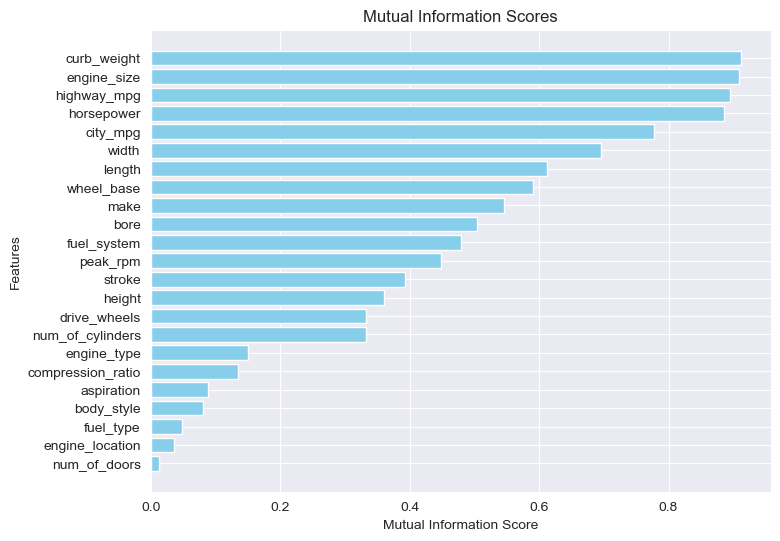

In [9]:
# Calculate and sort mutual information scores
mi_scores = mutual_info_regression(X_encoded, y, discrete_features=[col in discrete_features for col in X.columns])
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Printing sorted mutual information scores
print("Mutual Information Scores (sorted):")
for feature, score in mi_series.items():
    print(f"{feature}: {score}")

# Plotting with sorted values
plt.figure(figsize=(8, 6))
plt.barh(mi_series.index, mi_series.values, color="skyblue")
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.title('Mutual Information Scores')
plt.gca().invert_yaxis()  # To display the highest score at the top
plt.show()

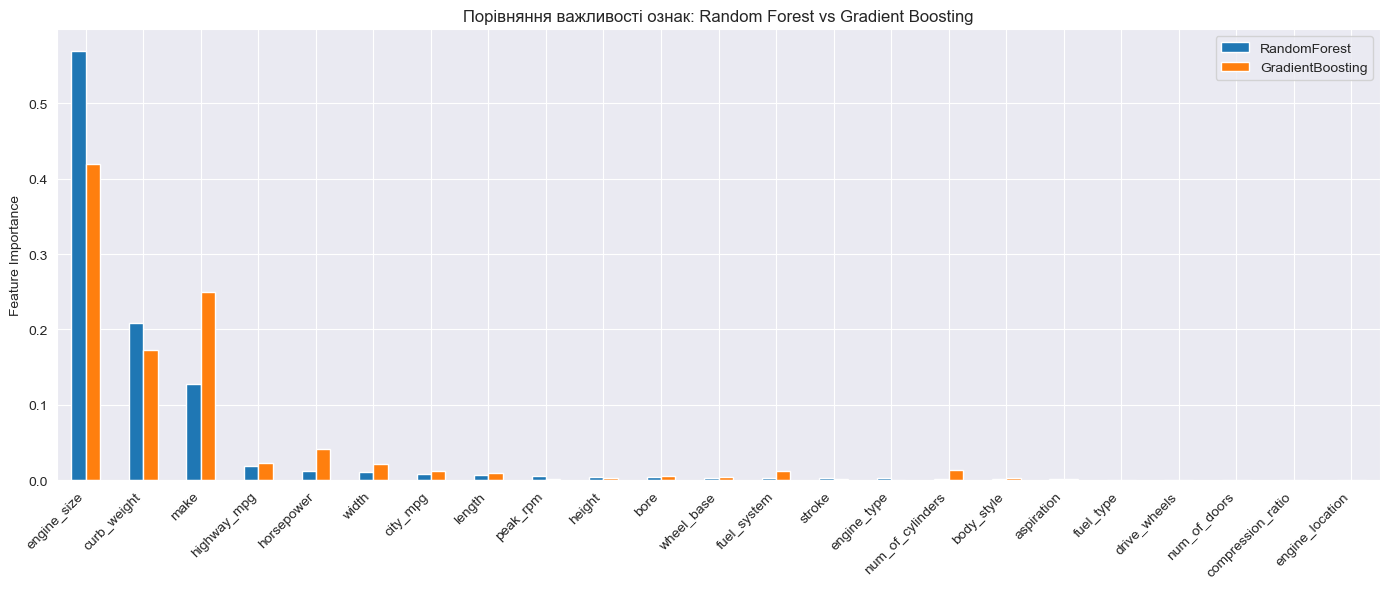

In [10]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt

# Модель Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_encoded, y)
rf_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)

# Модель Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=0)
gb.fit(X_encoded, y)
gb_importance = pd.Series(gb.feature_importances_, index=X_encoded.columns)

# Об'єднання у DataFrame
importance_df = pd.DataFrame({
    'RandomForest': rf_importance,
    'GradientBoosting': gb_importance
})

# Сортування за RF важливістю для зручності
importance_df_sorted = importance_df.sort_values(by='RandomForest', ascending=False)

# Побудова графіку
importance_df_sorted.plot(kind='bar', figsize=(14, 6))
plt.title('Порівняння важливості ознак: Random Forest vs Gradient Boosting')
plt.ylabel('Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# Створюємо загальний DataFrame з усіма оцінками
combined_scores = pd.DataFrame({
    'mutual_info': mi_series,
    'random_forest': rf_importance,
    'gradient_boosting': gb_importance
})

# Ранжування (нормалізоване: від 0 до 1)
ranked_scores = combined_scores.rank(pct=True)

# Вивід
print("Нормалізовані рангові оцінки:")
print(ranked_scores.sort_values(by='mutual_info', ascending=False))

Нормалізовані рангові оцінки:
                   mutual_info  random_forest  gradient_boosting
curb_weight           1.000000       0.956522           0.913043
engine_size           0.956522       1.000000           1.000000
highway_mpg           0.913043       0.869565           0.826087
horsepower            0.869565       0.826087           0.869565
city_mpg              0.826087       0.739130           0.652174
width                 0.782609       0.782609           0.782609
length                0.739130       0.695652           0.608696
wheel_base            0.695652       0.521739           0.521739
make                  0.652174       0.913043           0.956522
bore                  0.608696       0.565217           0.565217
fuel_system           0.565217       0.478261           0.695652
peak_rpm              0.521739       0.652174           0.304348
stroke                0.478261       0.434783           0.347826
height                0.434783       0.608696           0.43

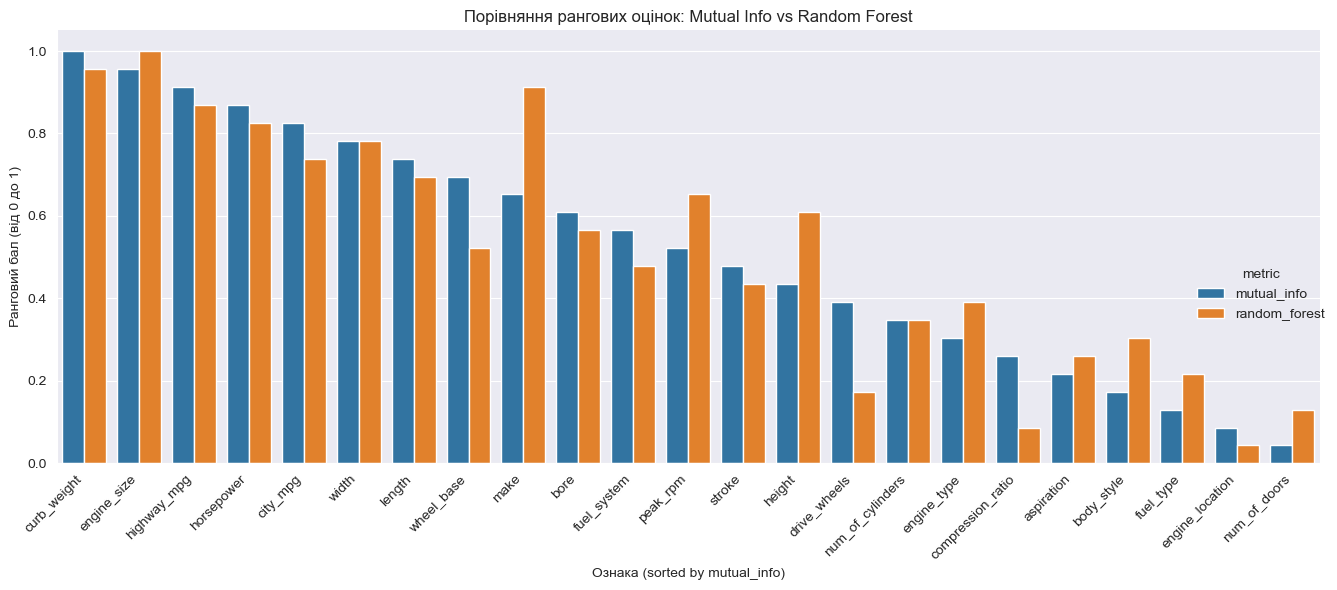

Топ ознак за ранговими оцінками (сортовано за mutual_info):

                   mutual_info  random_forest
curb_weight           1.000000       0.956522
engine_size           0.956522       1.000000
highway_mpg           0.913043       0.869565
horsepower            0.869565       0.826087
city_mpg              0.826087       0.739130
width                 0.782609       0.782609
length                0.739130       0.695652
wheel_base            0.695652       0.521739
make                  0.652174       0.913043
bore                  0.608696       0.565217
fuel_system           0.565217       0.478261
peak_rpm              0.521739       0.652174
stroke                0.478261       0.434783
height                0.434783       0.608696
drive_wheels          0.391304       0.173913
num_of_cylinders      0.347826       0.347826
engine_type           0.304348       0.391304
compression_ratio     0.260870       0.086957
aspiration            0.217391       0.260870
body_style         

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Вибираємо лише дві метрики
ranked_subset = ranked_scores[['mutual_info', 'random_forest']]

# Сортуємо за mutual_info
ranked_sorted = ranked_subset.sort_values(by='mutual_info', ascending=False)

# Перетворення в long format
ranked_melted = ranked_sorted.reset_index().melt(
    id_vars='index',
    value_vars=['mutual_info', 'random_forest'],
    var_name='metric',
    value_name='rank_score'
)

# Перейменування для виводу
ranked_melted = ranked_melted.rename(columns={'index': 'feature'})

# Побудова grouped barplot
g = sns.catplot(
    data=ranked_melted,
    kind='bar',
    x='feature',
    y='rank_score',
    hue='metric',
    height=6,
    aspect=2
)

# Оформлення
plt.xticks(rotation=45, ha='right')
plt.title('Порівняння рангових оцінок: Mutual Info vs Random Forest')
plt.ylabel('Ранговий бал (від 0 до 1)')
plt.xlabel('Ознака (sorted by mutual_info)')
plt.tight_layout()
plt.show()

# Вивід в консоль у вигляді таблиці
print("Топ ознак за ранговими оцінками (сортовано за mutual_info):\n")
print(ranked_sorted)

## Аналіз важливості ознак (TargetEncoder + mutual_info + RandomForest)

---

### Топ ознаки з високим впливом (в обох метриках)

| Ознака        | Mutual Info | Random Forest |
|---------------|-------------|----------------|
| `curb_weight` | **1.00**    | **0.96**       |
| `engine_size` | **0.96**    | **1.00**       |
| `highway_mpg` | 0.91        | 0.87           |
| `horsepower`  | 0.87        | 0.83           |

Ці ознаки стабільно мають найвищі ранги в обох метриках — отже, є **надійними предикторами ціни (`price`)**. Вони пов’язані з потужністю, витратою пального, розмірами та вагою авто.

---

### Ознаки з високим mutual_info, але нижчою важливістю в моделі

| Ознака         | Mutual Info | Random Forest |
|----------------|-------------|----------------|
| `wheel_base`   | 0.70        | 0.52           |
| `fuel_system`  | 0.57        | 0.48           |
| `bore`         | 0.61        | 0.57           |
| `drive_wheels` | 0.39        | 0.17           |

Ці ознаки мають значну взаємну інформацію, але модель вважає їх **менш корисними при прогнозуванні**. Це може свідчити про:
- дублювання інформації іншими ознаками
- кореляцію з ключовими фічами (`curb_weight`, `length`)

---

### Ознаки з вищою важливістю в моделі, ніж у mutual_info

| Ознака         | Mutual Info | Random Forest |
|----------------|-------------|----------------|
| `make`         | 0.65        | **0.91**       |
| `peak_rpm`     | 0.52        | **0.65**       |
| `height`       | 0.43        | **0.61**       |
| `engine_type`  | 0.30        | **0.39**       |

Ці ознаки виявилися **значущими для моделі**, хоча `mutual_info` оцінює їх нижче. Ймовірно, модель вловила **нелінійні або складні взаємозв’язки**, які mutual_info не бачить (оскільки вона не враховує контекст інших ознак).

---

### Найменш важливі ознаки

| Ознака             | Mutual Info | Random Forest |
|--------------------|-------------|----------------|
| `engine_location`  | 0.09        | 0.04           |
| `num_of_doors`     | 0.04        | 0.13           |
| `fuel_type`        | 0.13        | 0.22           |
| `compression_ratio`| 0.26        | 0.09           |

😐 Ознаки, які мають **низький внесок** у пояснення `price`. Їх можна або **видалити**, або **трансформувати**, якщо потрібне спрощення моделі.

---

## Висновки:

1. Ознаки `curb_weight`, `engine_size`, `horsepower`, `highway_mpg` — **основні драйвери ціни** автомобіля.
2. Модель на основі TargetEncoder краще вловлює **категоріальні закономірності**, наприклад, у змінній `make` з використанням LabelEncoder це значення дорівнювало 0.83 проти 0.91 з TargetEncoder
3. `RandomForest` демонструє **вищу чутливість до комбінацій ознак**, ніж проста оцінка mutual_info.